In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/daily-climate-time-series-data/DailyDelhiClimateTrain.csv
/kaggle/input/daily-climate-time-series-data/DailyDelhiClimateTest.csv


In [2]:
df_train = pd.read_csv("/kaggle/input/daily-climate-time-series-data/DailyDelhiClimateTrain.csv")
df_test = pd.read_csv("/kaggle/input/daily-climate-time-series-data/DailyDelhiClimateTest.csv")

# Dataset Treinamento

In [3]:
df_train.shape

(1462, 5)

In [4]:
df_train.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [5]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1462 non-null   object 
 1   meantemp      1462 non-null   float64
 2   humidity      1462 non-null   float64
 3   wind_speed    1462 non-null   float64
 4   meanpressure  1462 non-null   float64
dtypes: float64(4), object(1)
memory usage: 57.2+ KB


In [6]:
df_train.isnull().sum()

date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64

In [7]:
print(df_train['date'].dtype)

object


In [8]:
# Convertendo a coluna 'data' para datetime
df_train['date'] = pd.to_datetime(df_train['date'], errors='coerce')

df_train['year'] = df_train['date'].dt.year
df_train['month'] = df_train['date'].dt.month
df_train['day'] = df_train['date'].dt.dayofyear

In [9]:
# Verificando se há valores que não foram convertidos
print(df_train[df_train['date'].isna()])

Empty DataFrame
Columns: [date, meantemp, humidity, wind_speed, meanpressure, year, month, day]
Index: []


In [10]:
df_train.shape

(1462, 8)

In [11]:
df_train.head()

,date,meantemp,humidity,wind_speed,meanpressure,year,month,day
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667,2013,1,1
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000,2013,1,2
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667,2013,1,3
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667,2013,1,4
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000,2013,1,5


In [12]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          1462 non-null   datetime64[ns]
 1   meantemp      1462 non-null   float64       
 2   humidity      1462 non-null   float64       
 3   wind_speed    1462 non-null   float64       
 4   meanpressure  1462 non-null   float64       
 5   year          1462 non-null   int32         
 6   month         1462 non-null   int32         
 7   day           1462 non-null   int32         
dtypes: datetime64[ns](1), float64(4), int32(3)
memory usage: 74.4 KB


In [13]:
print(df_train['year'].unique())

[2013 2014 2015 2016 2017]


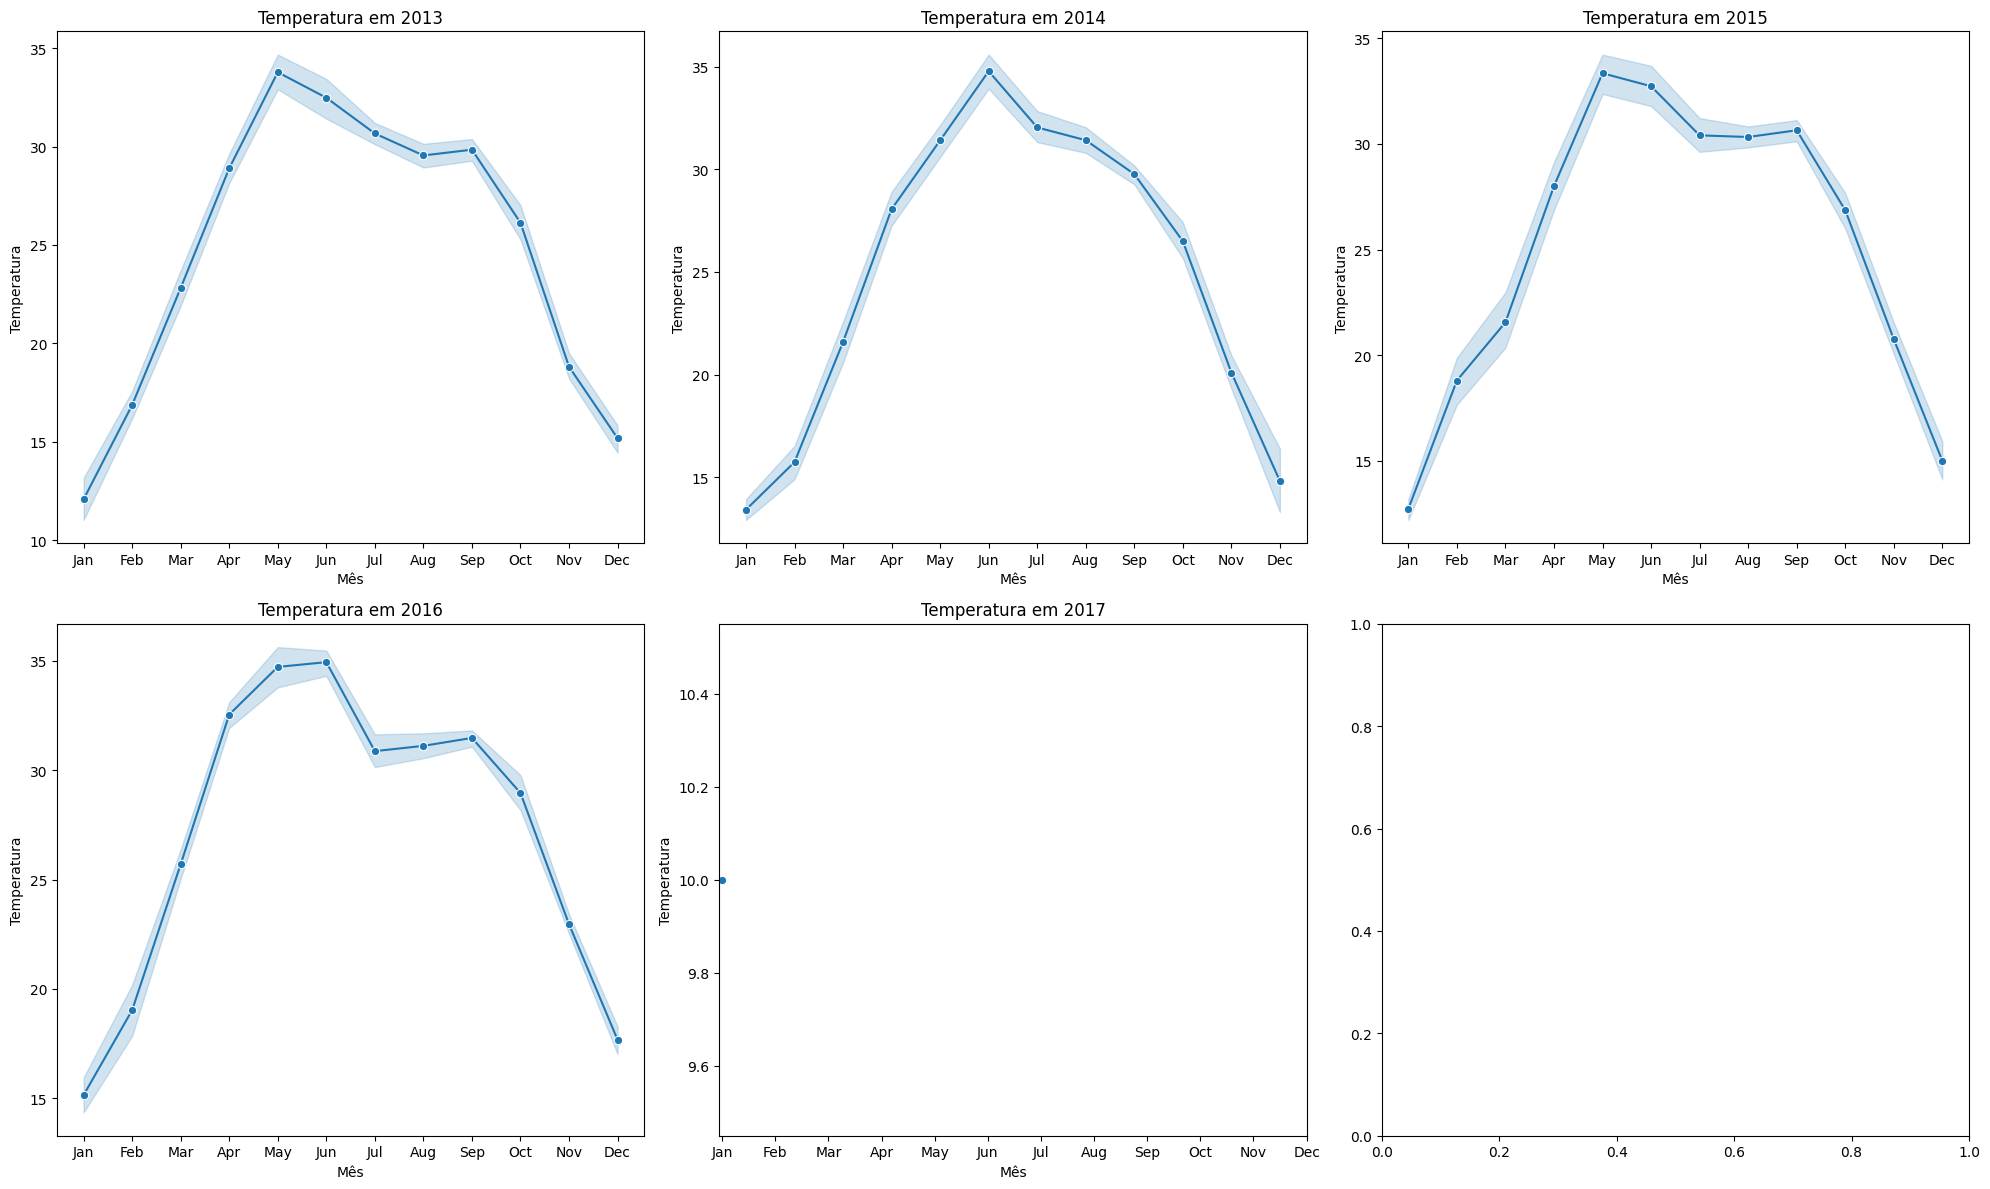

In [14]:
# Definindo os anos presentes no dataset
years = df_train['year'].unique()

# Criando uma figura com múltiplos subgráficos (2 linhas e 3 colunas, ajustando conforme necessário)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 12))  # Ajuste de acordo com a quantidade de anos
axes = axes.flatten()

# Gerando um gráfico para cada ano
for i, year in enumerate(years):
    # Filtrando os dados para o ano específico
    df_year = df_train[df_train['year'] == year]
    
    # Criando o gráfico de linha para o ano específico
    sns.lineplot(data=df_year, x='month', y='meantemp', marker='o', palette='Set2', ax=axes[i])
    
    # Configurando o título e rótulos do gráfico
    axes[i].set_title(f'Temperatura em {year}')
    axes[i].set_xlabel('Mês')
    axes[i].set_ylabel('Temperatura')
    axes[i].set_xticks(range(1, 13))
    axes[i].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# Ajustando o layout para melhor exibição
plt.tight_layout()
plt.show()


# Dataset Teste

In [15]:
df_test.shape

(114, 5)

In [16]:
df_test.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2017-01-01,15.913043,85.869565,2.743478,59.000000
1,2017-01-02,18.500000,77.222222,2.894444,1018.277778
2,2017-01-03,17.111111,81.888889,4.016667,1018.333333
3,2017-01-04,18.700000,70.050000,4.545000,1015.700000
4,2017-01-05,18.388889,74.944444,3.300000,1014.333333


In [17]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114 entries, 0 to 113
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          114 non-null    object 
 1   meantemp      114 non-null    float64
 2   humidity      114 non-null    float64
 3   wind_speed    114 non-null    float64
 4   meanpressure  114 non-null    float64
dtypes: float64(4), object(1)
memory usage: 4.6+ KB


In [18]:
df_test.isnull().sum()

date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64

In [19]:
print(df_test['date'].dtype)

object


In [20]:
# Convertendo a coluna 'data' para datetime
df_test['date'] = pd.to_datetime(df_test['date'], errors='coerce')

df_test['year'] = df_test['date'].dt.year
df_test['month'] = df_test['date'].dt.month
df_test['day'] = df_test['date'].dt.dayofyear

In [21]:
# Verificando se há valores que não foram convertidos
print(df_test[df_test['date'].isna()])

Empty DataFrame
Columns: [date, meantemp, humidity, wind_speed, meanpressure, year, month, day]
Index: []


In [22]:
df_test.shape

(114, 8)

In [23]:
df_test.head()

,date,meantemp,humidity,wind_speed,meanpressure,year,month,day
0,2017-01-01,15.913043,85.869565,2.743478,59.000000,2017,1,1
1,2017-01-02,18.500000,77.222222,2.894444,1018.277778,2017,1,2
2,2017-01-03,17.111111,81.888889,4.016667,1018.333333,2017,1,3
3,2017-01-04,18.700000,70.050000,4.545000,1015.700000,2017,1,4
4,2017-01-05,18.388889,74.944444,3.300000,1014.333333,2017,1,5


In [24]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114 entries, 0 to 113
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          114 non-null    datetime64[ns]
 1   meantemp      114 non-null    float64       
 2   humidity      114 non-null    float64       
 3   wind_speed    114 non-null    float64       
 4   meanpressure  114 non-null    float64       
 5   year          114 non-null    int32         
 6   month         114 non-null    int32         
 7   day           114 non-null    int32         
dtypes: datetime64[ns](1), float64(4), int32(3)
memory usage: 5.9 KB


In [25]:
print(df_test['year'].unique())

[2017]


# ML

In [26]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

In [27]:
# Variáveis independentes (features) e dependente (target)
X_train = df_train[['humidity', 'wind_speed', 'meanpressure', 'month', 'day']]  # Features
y_train = df_train['meantemp']  # Target (Temperatura média)

X_test = df_test[['humidity', 'wind_speed', 'meanpressure', 'month', 'day']]  # Features
y_test = df_test['meantemp']  # Target (Temperatura média)


In [28]:
# Inicializando o modelo de Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Treinando o modelo
rf_model.fit(X_train, y_train)

# Fazendo previsões
y_pred_rf = rf_model.predict(X_test)

# Avaliação do modelo
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f'Mean Squared Error (Random Forest): {mse_rf}')
print(f'R-squared (Random Forest): {r2_rf}')

Mean Squared Error (Random Forest): 8.802959202832747
R-squared (Random Forest): 0.7804512072726113


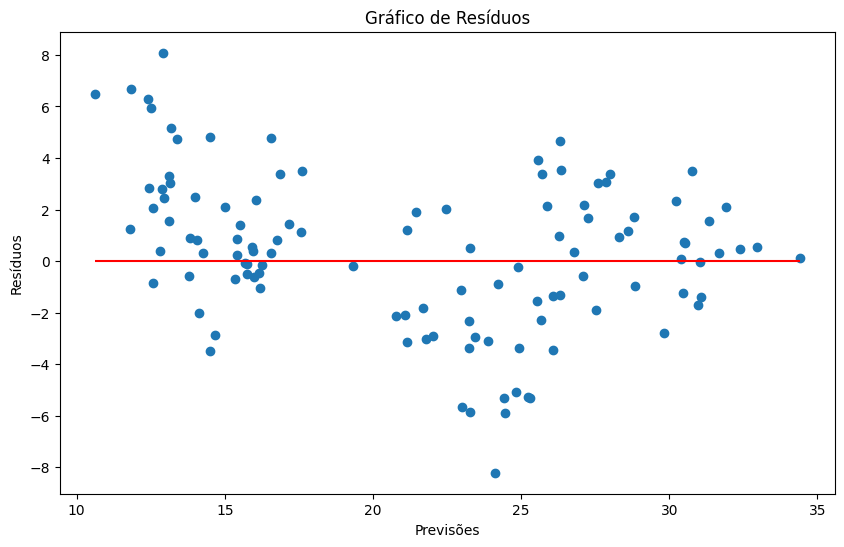

In [29]:
residuals = y_test - y_pred_rf

plt.figure(figsize=(10,6))
plt.scatter(y_pred_rf, residuals)
plt.hlines(0, xmin=min(y_pred_rf), xmax=max(y_pred_rf), color='red')
plt.xlabel('Previsões')
plt.ylabel('Resíduos')
plt.title('Gráfico de Resíduos')
plt.show()


**Voltaremos nesse módelo para entender melhor sobre os resíduos**